In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(seed=0)

X_min = 0
X_max = 2.5
X_n = 30

Dist_s = [0.4, 0.8]
Dist_w = [0.8, 1.6]
Pi = 0.5

X_col = ['cornflowerblue', 'gray']

X = np.zeros(X_n)
T = np.zeros(X_n, dtype=np.uint8)

for n in range(X_n):
    wk = np.random.rand()
    T[n] = 0 * (wk < Pi) + 1 * (wk >= Pi)
    X[n] = np.random.rand() * Dist_w[T[n]] + Dist_s[T[n]]

In [2]:
print("X = ", np.round(X,2))
print("T = ", T)

X =  [1.94 1.67 0.92 1.11 1.41 1.65 2.28 0.47 1.07 2.19 2.08 1.02 0.91 1.16
 1.46 1.02 0.85 0.89 1.79 1.89 0.75 0.9  1.87 0.5  0.69 1.5  0.96 0.53
 1.21 0.6 ]
T =  [1 1 0 0 1 1 1 0 0 1 1 0 0 0 1 0 0 0 1 1 0 1 1 0 0 1 1 0 1 0]


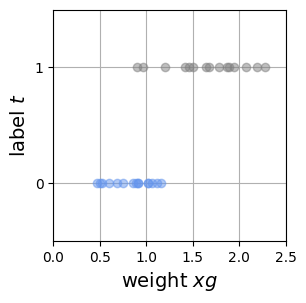

In [3]:
# week7_1.txt
# 데이터 분포 표시
def show_data1(x, t):
    K = np.max(t) + 1
    
    for k in range(K): # (A)
        plt.plot(x[t == k], t[t == k], X_col[k], alpha = 0.5, linestyle = 'none', marker = 'o')
        # t == k 일 때, x 와 t만을 추출하여 플롯하는 명령
        # 즉, x[t==0] 을 사용하면 t == 0을 채우는 인덱스만 추출 되므로 매우 편리
        plt.grid(True)
        plt.ylim(-.5, 1.5)
        plt.xlim(X_min, X_max)
        plt.yticks([0, 1])
        plt.xlabel('weight $xg$', fontsize = 14)
        plt.ylabel('label $t$', fontsize =14)
        

fig = plt.figure(figsize = (3, 3))
show_data1(X, T)
plt.show()

In [4]:
def logistic(x, w):
    y = 1 / (1 + np.exp(-(w[0] * x + w[1])))
    return y

In [5]:
def show_logistic(w):
    xb = np.linspace(X_min, X_max, 100)
    y = logistic(xb, w)
    plt.plot(xb, y, color='gray', linewidth=4)

    i = np.min(np.where(y > 0.5))
    B = (xb[i - 1] + xb[i]) / 2

    plt.plot([B, B], [-0.5, 1.5], color='k', linestyle='--')
    plt.title("Logistic Regression Model\n$w_0={0}, w_1={1}$".format(w[0], w[1]), fontsize=14)
    plt.grid(True)

    return B


np.float64(1.25)

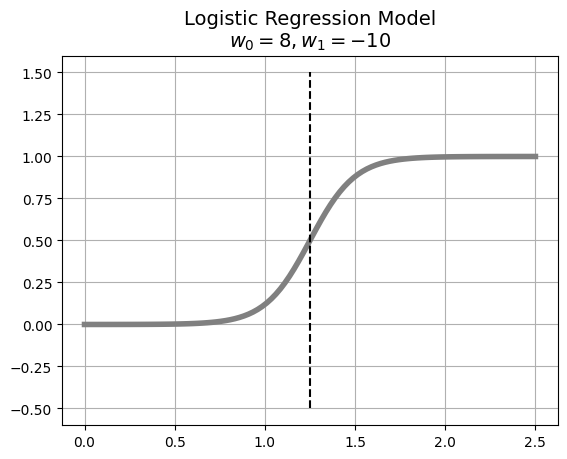

In [6]:
W = [8, -10]
show_logistic(W)

In [7]:
def cee_logistic(w, x, t):
    y = logistic(x, w)
    cee = 0

    for n in range(len(y)):
        cee = cee - (t[n] * np.log(y[n]) + (1 - t[n]) * np.log(1 - y[n]))

    cee = cee / X_n

    return cee

In [8]:
W = [1, 1]
cee_logistic(W, X, T)

np.float64(1.0288191541851066)

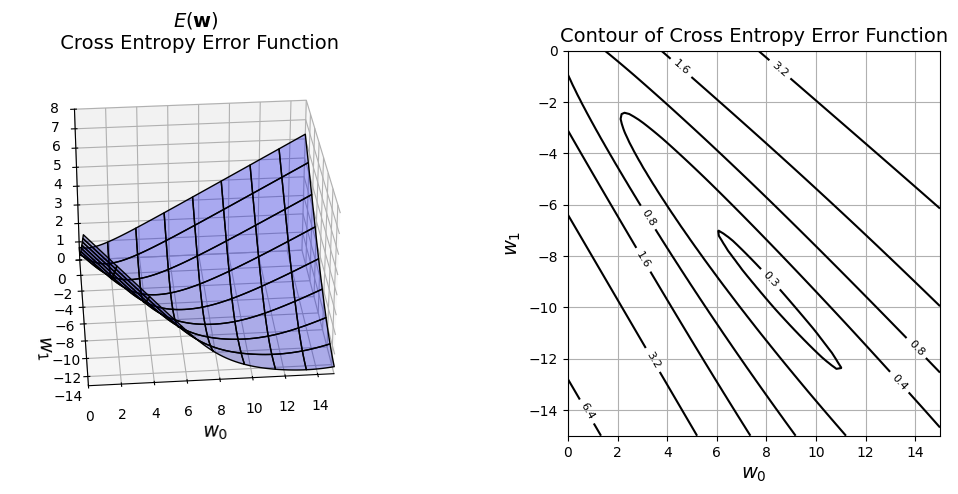

In [9]:
# week7_2.txt

# 평균 교차 엔트로피 오차의 plot
from mpl_toolkits.mplot3d import Axes3D

# 계산
xn = 80 # 등고선의 표시 해상도
w_range = np.array([[0, 15], [-15, 0]])
x0 = np.linspace(w_range[0, 0], w_range[0, 1], xn)
x1 = np.linspace(w_range[1, 0], w_range[1,1], xn)
xx0, xx1 = np.meshgrid(x0, x1)
C =np.zeros((len(x1), len(x0)))
w = np.zeros(2)

for i0 in range(xn):
    for i1 in range(xn):
        w[0] = x0[i0]
        w[1] = x1[i1]
        C[i1, i0] = cee_logistic(w, X, T)

        
# 표시
plt.figure(figsize = (12, 5))
#plt.figure(figsize = (9.5, 4))
plt.subplots_adjust(wspace = 0.5)
ax = plt.subplot(1, 2, 1, projection = '3d')
ax.plot_surface(xx0, xx1, C, color = 'blue', edgecolor = 'black', rstride = 10, cstride = 10, alpha = 0.3)
ax.set_xlabel('$w_0$', fontsize = 14)
ax.set_ylabel('$w_1$', fontsize = 14)
ax.set_xlim(0, 15)
ax.set_ylim(-15, 0)
ax.set_zlim(0, 8)
ax.view_init(30, -95)
ax.set_title("$E(\\mathbf{w})$\n Cross Entropy Error Function", fontsize=14)

plt.subplot(1, 2, 2)
cont = plt.contour(xx0, xx1, C, 20, colors = 'black', levels = [0.26, 0.4, 0.8, 1.6, 3.2, 6.4])
cont.clabel(fmt = '%1.1f', fontsize = 8)
plt.xlabel('$w_0$', fontsize = 14)
plt.ylabel('$w_1$', fontsize = 14)
plt.title("Contour of Cross Entropy Error Function", fontsize=14)
plt.grid(True)
plt.show()